# Exploratory Data Analysis (EDA)

This notebook performs Exploratory Data Analysis (EDA) on the Heart Disease UCI dataset.
The objective of this analysis is to understand the structure of the data, identify patterns, handle missing values, and gain insights that will guide feature engineering and model selection in later stages of the MLOps pipeline.


## Dataset Description

- **Dataset Name:** Heart Disease UCI Dataset
- **Source:** UCI Machine Learning Repository
- **Problem Type:** Binary Classification
- **Target Variable:** Presence (1) or absence (0) of heart disease

The dataset contains patient health information such as age, sex, blood pressure, cholesterol levels, and heart rate, which are commonly used indicators for predicting heart disease risk.


## Data Acquisition

The dataset was downloaded directly from the UCI Machine Learning Repository using a programmatic approach to ensure reproducibility across different environments.
The raw data file was stored in the project's `data/` directory and later loaded into this notebook for analysis.


In [17]:
import urllib.request
import os

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
output_path = "../data/heart.csv"

os.makedirs("../data", exist_ok=True)

urllib.request.urlretrieve(url, output_path)

print("Downloaded to:", output_path)


Downloaded to: ../data/heart.csv


In [18]:
!pip install pandas numpy seaborn



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Cleaning and Preprocessing

The following preprocessing steps were performed:

- Replaced missing values represented by "?" with NaN.
- Converted all feature columns to numeric format.
- Converted the target variable into a binary label:
  - 0 → No heart disease
  - 1 → Presence of heart disease
- Missing values were imputed using the median of each feature.

These steps ensure the dataset is clean and suitable for machine learning model training.


In [19]:

## Load & Clean the Data

import pandas as pd
import numpy as np

columns = [
    "age","sex","cp","trestbps","chol","fbs",
    "restecg","thalach","exang","oldpeak",
    "slope","ca","thal","target"
]

df = pd.read_csv("../data/heart.csv", names=columns)
df.replace("?", np.nan, inplace=True)
df = df.astype(float)
df["target"] = (df["target"] > 0).astype(int)
df.fillna(df.median(), inplace=True)

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [20]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## Dataset Overview

- The dataset consists of multiple numerical features related to patient health.
- After preprocessing, no missing values remain in the dataset.
- All features are numeric, which simplifies scaling and model training.


## Class Distribution Analysis

The class distribution plot shows that the dataset is reasonably balanced between patients with and without heart disease.

This balance is important because it reduces the risk of model bias toward a single class and allows the use of standard evaluation metrics such as accuracy, precision, recall, and ROC-AUC.


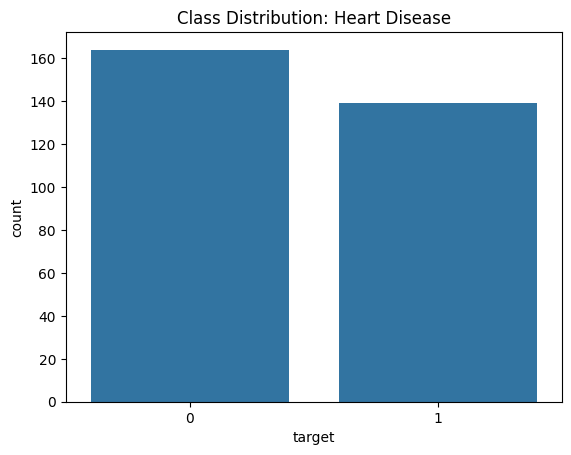

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)
plt.title("Class Distribution: Heart Disease")
plt.show()


## Feature Distribution Analysis

Histograms were plotted for all numerical features to understand their distributions.

Key observations:
- Age values are mostly concentrated between middle-aged and older patients.
- Cholesterol and resting blood pressure show noticeable variability.
- Some features are skewed, which motivates the use of feature scaling during model training.


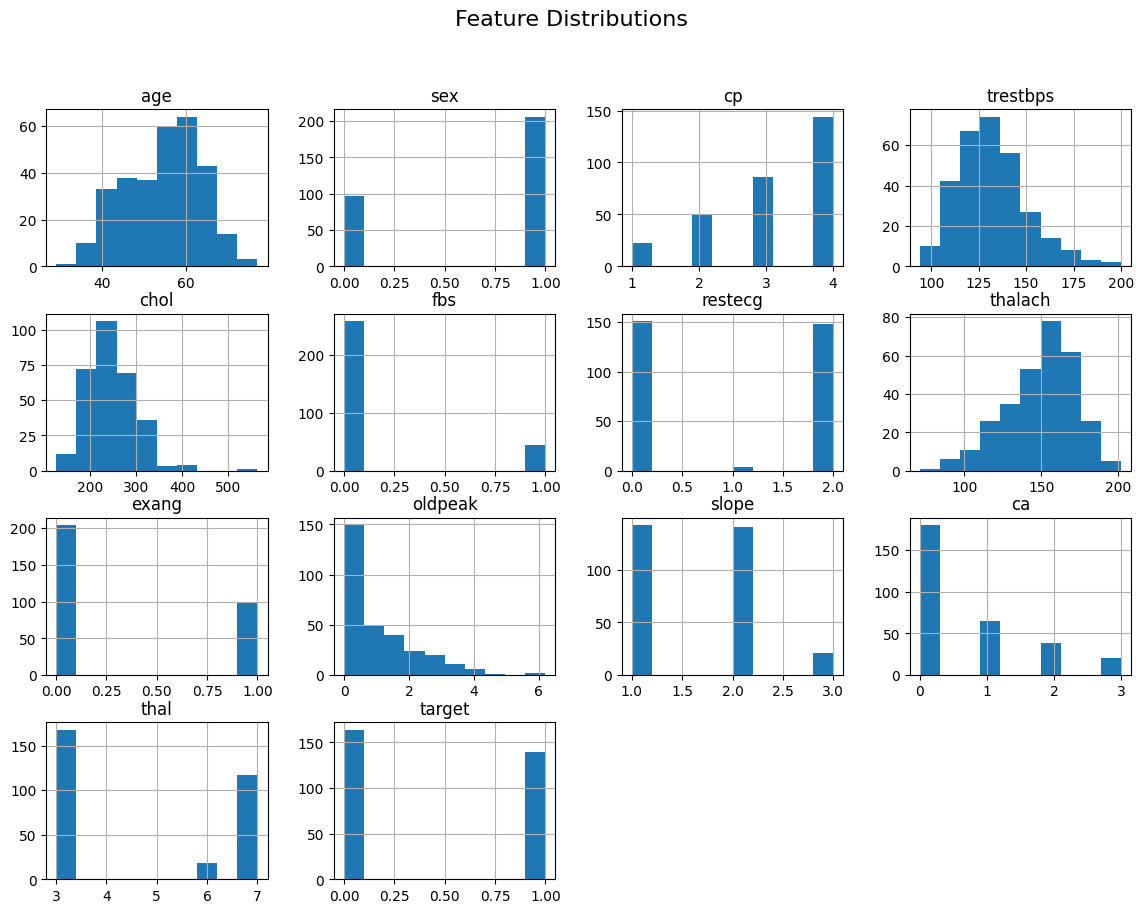

In [28]:
df.hist(figsize=(14,10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

## Correlation Analysis

A correlation heatmap was generated to examine relationships between features and the target variable.

Observations:
- Features such as age, maximum heart rate, and chest pain type show noticeable correlation with the target.
- Some features are moderately correlated with each other, but no extreme multicollinearity is observed.
- These correlations suggest that the dataset contains meaningful signals for predicting heart disease.


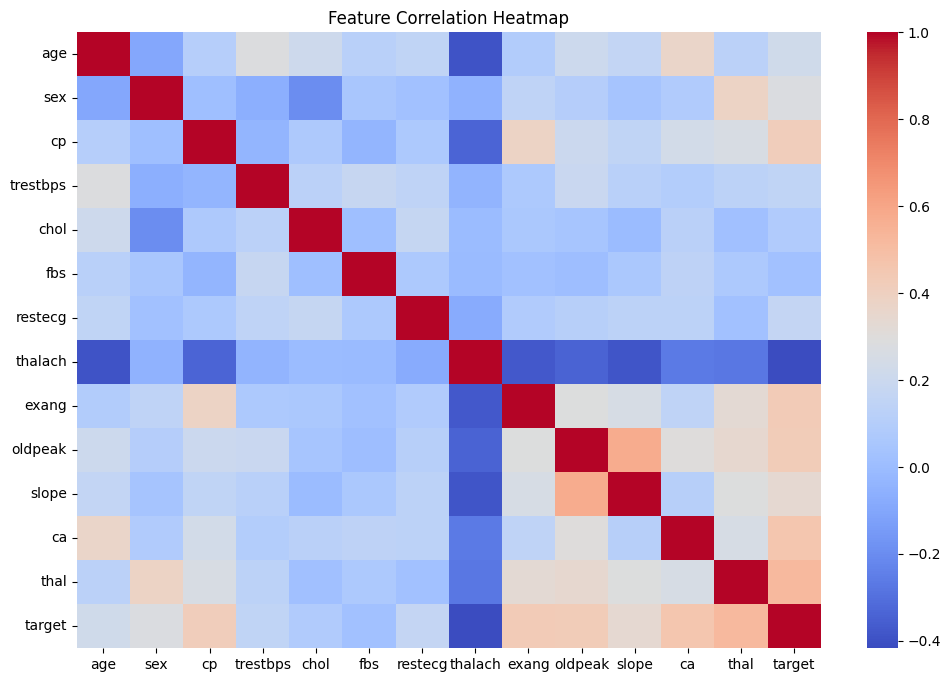

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

## EDA Summary and Conclusion

The exploratory data analysis provided the following key insights:

- The dataset is clean and suitable for supervised machine learning.
- The target variable is reasonably balanced.
- Several features show meaningful relationships with heart disease.
- Feature scaling will be required due to differences in value ranges.

Based on these observations, the dataset is well-prepared for feature engineering and model development in the subsequent stages of the MLOps pipeline.
